# DATA266 Lab 1 - Task 1
## GPT-style character-level language model, built from scratch (zohebw)

TinyStories · no `nn.Transformer*`, no `nn.MultiheadAttention`, no fused scaled-dot-product attention.

This notebook documents the completed run `t1_baseline_20260919-232507`. Training itself is run
from the command line (`src/train.py --config configs/gpt_baseline.yaml`) so that every run is
config-driven and logged; this notebook loads that run's artifacts and shows the results.

In [1]:
import json, sys
from pathlib import Path
def _find_root(start=None):
    # Walk up to the repo root (the directory holding common/ and requirements.txt)
    # so the notebook runs from anywhere - no hard-coded personal paths (workplan 5).
    p = (start or Path.cwd()).resolve()
    for cand in (p, *p.parents):
        if (cand/'common'/'config.py').exists() and (cand/'requirements.txt').exists():
            return cand
    raise RuntimeError('repo root not found from %s' % p)
ROOT = _find_root()
sys.path.insert(0, str(ROOT)); sys.path.insert(0, str(ROOT/'task1_llm/zoheb_waghu/src'))
import torch, numpy as np, pandas as pd
from common.config import load_config
RUN = 't1_baseline_20260919-232507'
MEMBER = ROOT/'task1_llm/zoheb_waghu'
cfg = load_config(MEMBER/'configs/gpt_baseline.yaml')
print('torch', torch.__version__, '| mps', torch.backends.mps.is_available())
print('run', RUN)

torch 2.5.1 | mps True
run t1_baseline_20260919-232507


## 1. Configuration

Every hyperparameter comes from the YAML - nothing is hard-coded here.

In [2]:
import yaml
print(yaml.safe_dump({k: v for k, v in cfg.items() if k in ('run','data','model','train','generate','eval')},
                     sort_keys=False, default_flow_style=False))

run:
  tag: t1_baseline
  member: zoheb_waghu
  seed: 1337
  device: auto
data:
  dataset: roneneldan/TinyStories
  split_source: train
  train_chars: 100000
  val_chars: 10000
  block_size: 256
  vocab_from: train_only
  cache_dir: /Users/zohebw/Desktop/DATA 266/data266-lab1/task1_llm/zoheb_waghu/data_processed
model:
  n_layer: 4
  n_head: 4
  n_embd: 256
  dropout: 0.1
  pos_embedding: learned
  tie_weights: false
  bias: true
train:
  epochs: 12
  steps_per_epoch: 120
  batch_size: 32
  optimizer: adamw
  lr: 0.0003
  min_lr: 3.0e-05
  betas:
  - 0.9
  - 0.95
  weight_decay: 0.1
  grad_clip: 1.0
  warmup_steps: 150
  schedule: cosine
  eval_interval_steps: 100
  log_interval_steps: 10
generate:
  prompts:
  - Once upon a time
  - The little girl
  - Tom and Jane went
  max_new_tokens: 400
  strategies:
  - name: greedy
  - name: temperature
    temperature: 0.8
  - name: temperature
    temperature: 1.2
eval:
  ngram_max: 3
  repeat_ngram_n: 4
  causal_mask_probe: true



## 2. Data preprocessing (5 marks)

100K training characters / 10K validation, character-level, with `char_to_idx` / `idx_to_char`
built from the **training split only**. Targets are inputs shifted right by one.

In [3]:
stats = json.loads((MEMBER/'data_processed/stats.json').read_text())
vocab_json = json.loads((MEMBER/'data_processed/vocab.json').read_text())['char_to_idx']
print(json.dumps(stats, indent=2))
print('\nvocabulary (%d chars):' % len(vocab_json))
print(''.join(sorted(c for c in vocab_json if c.isprintable()))[:120])

{
  "train_chars": 100000,
  "val_chars": 10000,
  "vocab_size": 73,
  "val_oov_chars": 0
}

vocabulary (73 chars):
 !"',-.01234567:;?ABCDEFGHIJKLMNOPRSTVWYabcdefghijklmnopqrstuvwxyz¦âœ€™


In [4]:
train_ids = np.load(MEMBER/'data_processed/train_ids.npy')
itos = {i: c for c, i in vocab_json.items()}
decode = lambda a: ''.join(itos[int(i)] for i in a)
x = train_ids[:64]; y = train_ids[1:65]          # target = input shifted right by one
print('input :', repr(decode(x)))
print('target:', repr(decode(y)))
print('\nshift verified:', bool((train_ids[1:65] == y).all()))

input : 'Once upon a time, there was a little bird named Flappy. Flappy w'
target: 'nce upon a time, there was a little bird named Flappy. Flappy wa'

shift verified: True


## 3. Model (15 marks)

Implemented in [src/model.py](src/model.py). Attention, causal masking, head split/merge,
layer norm, FFN, residuals and both embedding tables are all written out explicitly.

In [5]:
from model import GPT, CausalSelfAttention
import inspect
print(inspect.getsource(CausalSelfAttention.forward))

    def forward(self, x: torch.Tensor, return_attn: bool = False):
        B, T, C = x.shape
        q, k, v = self.qkv(x).split(C, dim=2)
        # (B, T, C) -> (B, n_head, T, head_dim)
        q = q.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.head_dim).transpose(1, 2)

        att = (q @ k.transpose(-2, -1)) * self.scale          # (B, nh, T, T)
        att = att.masked_fill(~self.causal_mask[:, :, :T, :T], float("-inf"))
        att = F.softmax(att, dim=-1)
        att = self.attn_dropout(att)

        y = att @ v                                            # (B, nh, T, hd)
        y = y.transpose(1, 2).contiguous().view(B, T, C)       # merge heads
        y = self.resid_dropout(self.proj(y))
        return (y, att) if return_attn else y



In [6]:
m = cfg['model']
model = GPT(stats['vocab_size'], m['n_layer'], m['n_head'], m['n_embd'],
            cfg['data']['block_size'], m['dropout'], m['bias'], m['tie_weights'])
ckpt = torch.load(MEMBER/f'checkpoints/{RUN}_best.pt', map_location='cpu', weights_only=False)
model.load_state_dict(ckpt['model']); model.eval()
print('parameters:', f"{model.num_params():,}")
print('best epoch:', ckpt['epoch'], '| val loss:', round(ckpt['val_loss'], 5))
model

parameters: 3,262,464
best epoch: 11 | val loss: 1.41941


GPT(
  (tok_emb): Embedding(73, 256)
  (pos_emb): Embedding(256, 256)
  (drop): Dropout(p=0.1, inplace=False)
  (blocks): ModuleList(
    (0-3): 4 x Block(
      (ln1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (attn): CausalSelfAttention(
        (qkv): Linear(in_features=256, out_features=768, bias=True)
        (proj): Linear(in_features=256, out_features=256, bias=True)
        (attn_dropout): Dropout(p=0.1, inplace=False)
        (resid_dropout): Dropout(p=0.1, inplace=False)
      )
      (ln2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (ffn): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=256, out_features=1024, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=1024, out_features=256, bias=True)
          (3): Dropout(p=0.1, inplace=False)
        )
      )
    )
  )
  (ln_f): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (lm_head): Linear(in_features=256, out_features=73,

### 3.1 Causal mask verified behaviourally

Not a picture of the mask - a perturbation test. Change the token at position *j* and confirm the
logits at every position *i < j* are **bit-identical**, while positions at and after *j* move.

In [7]:
from evaluate import causal_mask_probe
probe = causal_mask_probe(model, stats['vocab_size'], cfg['data']['block_size'], torch.device('cpu'))
print(json.dumps(probe, indent=2))
assert probe['passed'], 'causal mask leaks future information'
print('\nPASS: logits before position j are unchanged (delta = %.1f); positions from j move (delta = %.4f)'
      % (probe['max_logit_delta_before_j'], probe['min_logit_delta_from_j']))

{
  "probe_position": 128,
  "max_logit_delta_before_j": 0.0,
  "min_logit_delta_from_j": 4.082555770874023,
  "passed": true
}

PASS: logits before position j are unchanged (delta = 0.0); positions from j move (delta = 4.0826)


## 4. Training and loss curves (8 marks)

12 epochs, cross-entropy, 150-step warm-up then cosine decay.

In [8]:
hist = json.loads((MEMBER/f'outputs/history_{RUN}.json').read_text())
df = pd.DataFrame(hist['history'])
df['gap'] = df['loss'] - df['train_loss']
df[['epoch','train_loss','loss','perplexity','bits_per_char','top1_next_char_acc','gap']].round(4)

,epoch,train_loss,loss,perplexity,bits_per_char,top1_next_char_acc,gap
0,0,2.8244,2.3741,10.7418,3.4252,0.3196,-0.4503
1,1,2.2990,2.2642,9.6232,3.2665,0.3362,-0.0349
2,2,2.2013,2.1235,8.3605,3.0636,0.3658,-0.0778
3,3,2.0566,1.9502,7.0300,2.8135,0.4185,-0.1064
4,4,1.8909,1.7862,5.9668,2.5770,0.4688,-0.1047
5,5,1.7302,1.6642,5.2813,2.4009,0.5062,-0.0660
6,6,1.6087,1.5793,4.8515,2.2784,0.5325,-0.0294
7,7,1.5139,1.5193,4.5689,2.1918,0.5533,0.0054
8,8,1.4419,1.4804,4.3946,2.1357,0.5607,0.0384
9,9,1.3943,1.4521,4.2722,2.0950,0.5726,0.0578


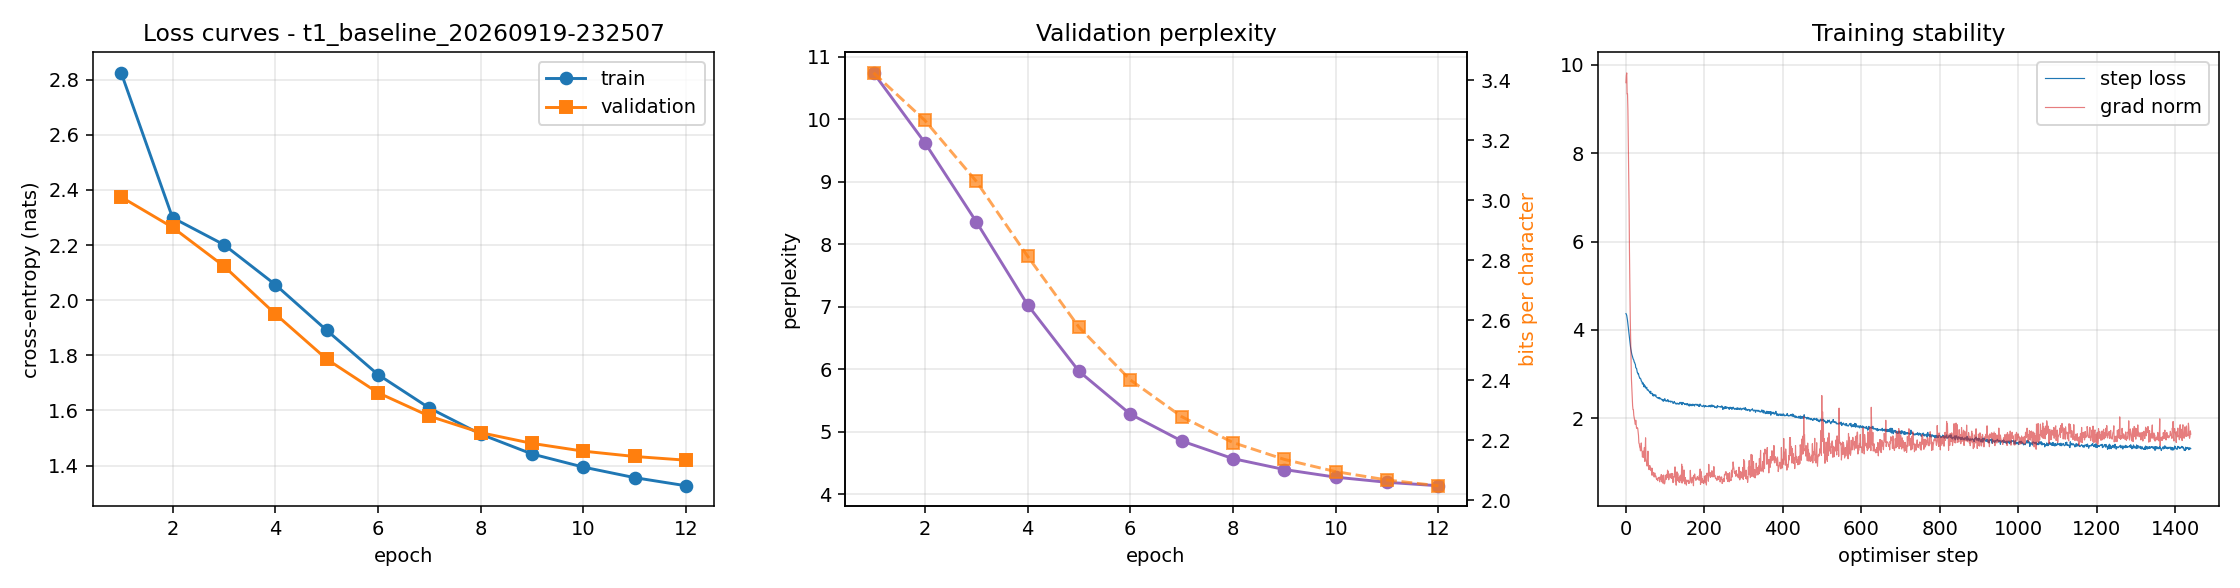

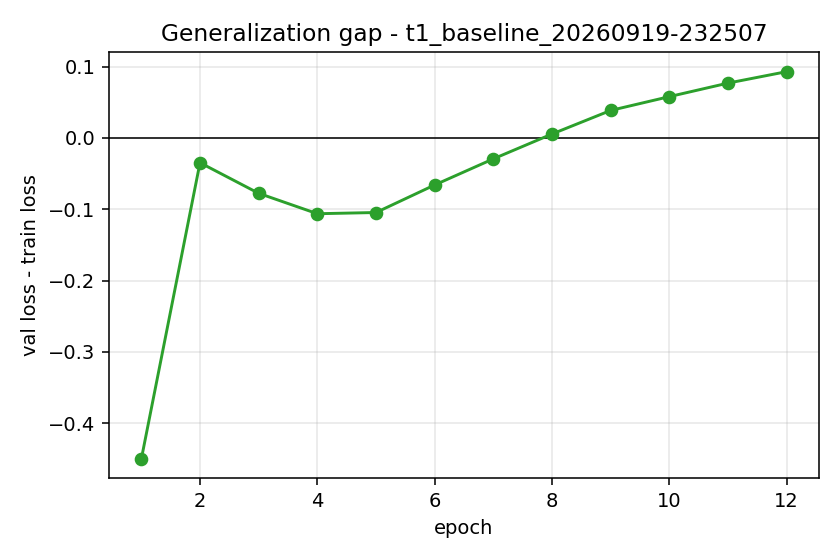

In [9]:
from IPython.display import Image, display
display(Image(filename=str(MEMBER/f'outputs/plots/loss_curves_{RUN}.png')))
display(Image(filename=str(MEMBER/f'outputs/plots/generalization_gap_{RUN}.png')))

In [10]:
gn = hist['grad_norms']; sl = hist['step_losses']
print('steps: %d | grad norm mean %.4f max %.4f' % (len(gn), np.mean(gn), np.max(gn)))
print('NaNs: %d | non-finite losses: %d' % (sum(not np.isfinite(g) for g in gn),
                                            sum(not np.isfinite(l) for l in sl)))
print('validation loss decreased every epoch:', bool((df["loss"].diff().dropna() < 0).all()))

steps: 1440 | grad norm mean 1.3888 max 9.8162
NaNs: 0 | non-finite losses: 0
validation loss decreased every epoch: True


## 5. Text generation

Greedy and temperature sampling, 3 prompts x 3 strategies.

In [11]:
print((MEMBER/f'outputs/samples/samples_{RUN}.txt').read_text()[:1500])

### greedy | prompt='Once upon a time'
Once upon a time, there was a little girl named Lily. She loved to play and said, "What is a looked around and said, "I will you can be starte."

The little girl named Lily was so happy. They loved to the bird and said, "I will you can be to the careful and said, "I will you you can to the careful and said, "I will you you can to the careful and said, "I will you you can to the care and said, "I will you you can 

### temperature=0.8 | prompt='Once upon a time'
Once upon a time, the the prink, it was priteds coming the rinceds.

Once upon a time, there was alwas so little girl named One day, Timmy whanted to grabbe bad so the rave meazing. He laughed to the bally hof with a saw so careful the birds never when him he got he was he onexind to fun. He saw happy an Aftelw a sign the asked the chear on her happy it a bird in the who conther an the it.

They loved ther and sa

### temperature=1.2 | prompt='Once upon a time'
Once upon a time wias so happ

In [12]:
from evaluate import distinct_n, repeated_ngram_rate
import re
blocks = re.split(r'### ', (MEMBER/f'outputs/samples/samples_{RUN}.txt').read_text())[1:]
groups = {}
for b in blocks:
    head, body = b.split('\n', 1)
    groups.setdefault(head.split(' | ')[0].strip(), []).append(body)
rows = [{'strategy': k, 'distinct_1': distinct_n('\n'.join(v),1), 'distinct_2': distinct_n('\n'.join(v),2),
         'distinct_3': distinct_n('\n'.join(v),3), 'repeated_4gram': repeated_ngram_rate('\n'.join(v),4)}
        for k, v in groups.items()]
pd.DataFrame(rows).round(4)

,strategy,distinct_1,distinct_2,distinct_3,repeated_4gram
0,greedy,0.0287,0.1434,0.2464,0.6824
1,temperature=0.8,0.0342,0.2207,0.4984,0.3081
2,temperature=1.2,0.0383,0.2690,0.6062,0.1894


## 6. All required metrics

Each run writes **both** tables: `metrics_report.csv` in the team-agreed column schema (so my
numbers line up with my teammate's) and `metrics_report_extended.csv` with the columns the team
header omits. Both writers reject a row missing a required column, so neither can silently drop
a metric.

In [13]:
team = pd.read_csv(MEMBER/'metrics_report.csv')          # team-agreed schema
ext  = pd.read_csv(MEMBER/'metrics_report_extended.csv')  # my full set
print('team schema columns: %d | extended: %d' % (len(team.columns), len(ext.columns)))
print('in extended but not in the team header (renames + genuine extras):')
print(' ', sorted(set(ext.columns) - set(team.columns)))
row = ext[ext.run_id == RUN].T
row.columns = ['value']
row

team schema columns: 22 | extended: 25
in extended but not in the team header (renames + genuine extras):
  ['bits_per_char', 'checkpoint_id', 'config_path', 'device', 'model_name', 'param_count', 'top1_next_char_acc', 'total_train_seconds', 'train_loss', 'val_loss']


,value
run_id,t1_baseline_20260919-232507
model_name,t1_baseline
config_path,task1_llm/zohebw/configs/gpt_baseline.yaml
checkpoint_id,t1_baseline_20260919-232507_best.pt
train_loss,1.17207
val_loss,1.41941
perplexity,4.1347
bits_per_char,2.04778
generalization_gap,0.24734
top1_next_char_acc,0.58264


## 7. Failure analysis (2 marks)

Three cases with the verbatim generated text, failure type and observation:
[failure_analysis.md](failure_analysis.md).

1. **Degenerate repetition loop** under greedy decoding - repeated-4-gram rate 0.68 vs 0.19 at temperature 1.2
2. **Broken morphology** - phonotactically plausible non-words (`phatt`, `angrion`, `smaring`)
3. **Loss of coherence plus reproduced `â€` mojibake** - a preprocessing finding, not a modelling one

Full write-up and design justification: [results.md](results.md).